In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [4]:
# Load the real irrigation data from CSV

# Update this path to your actual CSV file location
csv_file = r'C:\Users\dell\Desktop\Smart irrigation system\irrigation_log_20251016.csv'

# Load the dataset
df = pd.read_csv(csv_file)

print("="*60)
print("REAL DATASET LOADED")
print("="*60)

print(f"\n✓ Dataset loaded successfully")
print(f"Total samples: {len(df)}")
print(f"Dataset shape: {df.shape}")

print("\nColumns in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset info:")
print(df.info())

REAL DATASET LOADED

✓ Dataset loaded successfully
Total samples: 49
Dataset shape: (49, 14)

Columns in dataset:
  1. Timestamp
  2. Date
  3. Time
  4. Soil_Moisture
  5. Soil_Status
  6. Temperature_C
  7. Humidity_Percent
  8. Weather_Description
  9. Weather_Temp_C
  10. Weather_Humidity
  11. Rain_Coming
  12. Decision
  13. Water_Saved_L
  14. Irrigation_Count

First 5 rows:
             Timestamp        Date      Time  Soil_Moisture Soil_Status  \
0  2025-10-14 20:18:19  2025-10-14  20:18:19             19         WET   
1  2025-10-14 20:19:20  2025-10-14  20:19:20             19         WET   
2  2025-10-14 20:20:21  2025-10-14  20:20:21            734         DRY   
3  2025-10-14 20:23:58  2025-10-14  20:23:58             20         WET   
4  2025-10-14 20:24:59  2025-10-14  20:24:59             18         WET   

   Temperature_C  Humidity_Percent Weather_Description  Weather_Temp_C  \
0           32.7              32.0               Clear            27.8   
1           32.8

In [5]:
# Clean and prepare the data for training

print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# Create a copy to work with
df_clean = df.copy()

# 1. Handle missing values
print("\nChecking for missing values:")
print(df_clean.isnull().sum())

# Drop rows with missing values (if any)
df_clean = df_clean.dropna()
print(f"\n✓ After dropping nulls: {len(df_clean)} samples")

# 2. Feature Engineering - Extract useful features from timestamp
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
df_clean['Hour'] = df_clean['Timestamp'].dt.hour
df_clean['DayOfWeek'] = df_clean['Timestamp'].dt.dayofweek
df_clean['Month'] = df_clean['Timestamp'].dt.month

# 3. Encode Rain_Coming (Yes/No to 1/0)
df_clean['Rain_Coming_Binary'] = df_clean['Rain_Coming'].map({'Yes': 1, 'No': 0})

# 4. Encode Soil_Status to numeric
soil_status_map = {'DRY': 0, 'MODERATE': 1, 'WET': 2}
df_clean['Soil_Status_Encoded'] = df_clean['Soil_Status'].map(soil_status_map)

# 5. Create days_since_rain feature (calculate from consecutive rain events)
df_clean['Days_Since_Rain'] = 0
rain_counter = 0
for i in range(len(df_clean)):
    if df_clean.iloc[i]['Rain_Coming_Binary'] == 1:
        rain_counter = 0
    else:
        rain_counter += 1
    df_clean.iloc[i, df_clean.columns.get_loc('Days_Since_Rain')] = rain_counter

print("\n✓ Feature engineering complete")
print("\nNew features added:")
print("  - Hour (0-23)")
print("  - DayOfWeek (0-6)")
print("  - Month (1-12)")
print("  - Rain_Coming_Binary (0/1)")
print("  - Soil_Status_Encoded (0/1/2)")
print("  - Days_Since_Rain")

print("\nProcessed dataset sample:")
print(df_clean[['Soil_Moisture', 'Temperature_C', 'Humidity_Percent', 
                'Rain_Coming_Binary', 'Days_Since_Rain', 'Hour', 'Decision']].head(10))

DATA PREPROCESSING

Checking for missing values:
Timestamp              0
Date                   0
Time                   0
Soil_Moisture          0
Soil_Status            0
Temperature_C          0
Humidity_Percent       0
Weather_Description    0
Weather_Temp_C         0
Weather_Humidity       0
Rain_Coming            0
Decision               0
Water_Saved_L          0
Irrigation_Count       0
dtype: int64

✓ After dropping nulls: 49 samples

✓ Feature engineering complete

New features added:
  - Hour (0-23)
  - DayOfWeek (0-6)
  - Month (1-12)
  - Rain_Coming_Binary (0/1)
  - Soil_Status_Encoded (0/1/2)
  - Days_Since_Rain

Processed dataset sample:
   Soil_Moisture  Temperature_C  Humidity_Percent  Rain_Coming_Binary  \
0             19           32.7              32.0                   0   
1             19           32.8              32.0                   0   
2            734           32.8              32.0                   0   
3             20           32.8              3

CURRENT DECISION DISTRIBUTION

Decision counts:
Decision
STOP        37
IRRIGATE    12
Name: count, dtype: int64

Decision percentages:
Decision
STOP        75.510204
IRRIGATE    24.489796
Name: proportion, dtype: float64


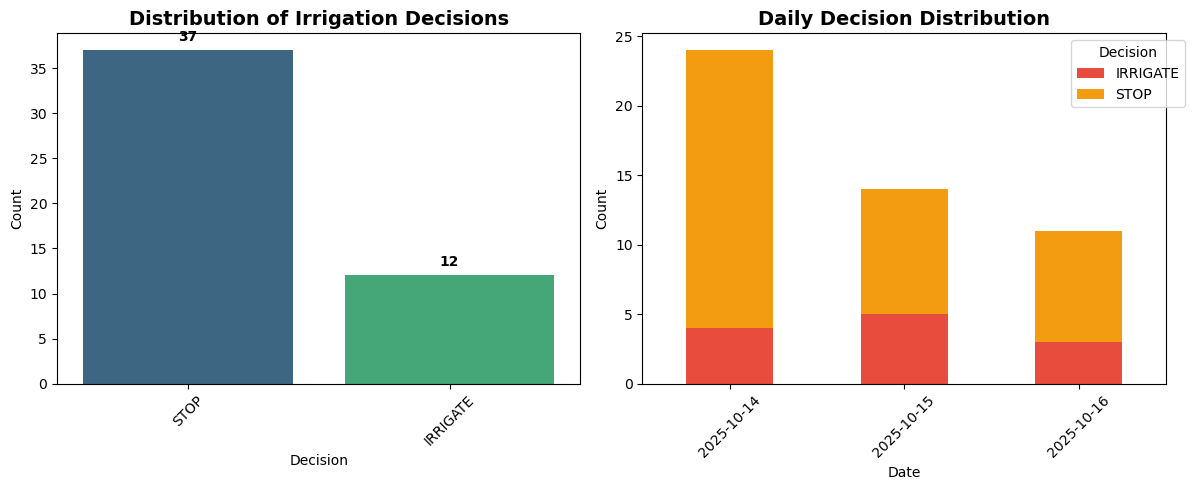


CLASS BALANCE CHECK
Minimum samples in any class: 12
✓ Good class distribution for training


In [6]:
# Analyze the decisions currently being made by the rule-based system

print("="*60)
print("CURRENT DECISION DISTRIBUTION")
print("="*60)

# Decision counts
decision_counts = df_clean['Decision'].value_counts()
print("\nDecision counts:")
print(decision_counts)

print("\nDecision percentages:")
print(df_clean['Decision'].value_counts(normalize=True) * 100)

# Visualize decision distribution
plt.figure(figsize=(12, 5))

# Subplot 1: Decision counts
plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='Decision', palette='viridis', order=decision_counts.index)
plt.title('Distribution of Irrigation Decisions', fontsize=14, fontweight='bold')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, v in enumerate(decision_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

# Subplot 2: Decision over time
plt.subplot(1, 2, 2)
df_clean['Date'] = df_clean['Timestamp'].dt.date
daily_decisions = df_clean.groupby(['Date', 'Decision']).size().unstack(fill_value=0)
daily_decisions.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#e74c3c', '#f39c12', '#27ae60'])
plt.title('Daily Decision Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend(title='Decision', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Check if we have enough samples for each class
print("\n" + "="*60)
print("CLASS BALANCE CHECK")
print("="*60)
min_samples = decision_counts.min()
print(f"Minimum samples in any class: {min_samples}")

if min_samples < 10:
    print("⚠️  WARNING: Some classes have very few samples!")
    print("   Consider collecting more data for better model training.")
else:
    print("✓ Good class distribution for training")

FEATURE ANALYSIS


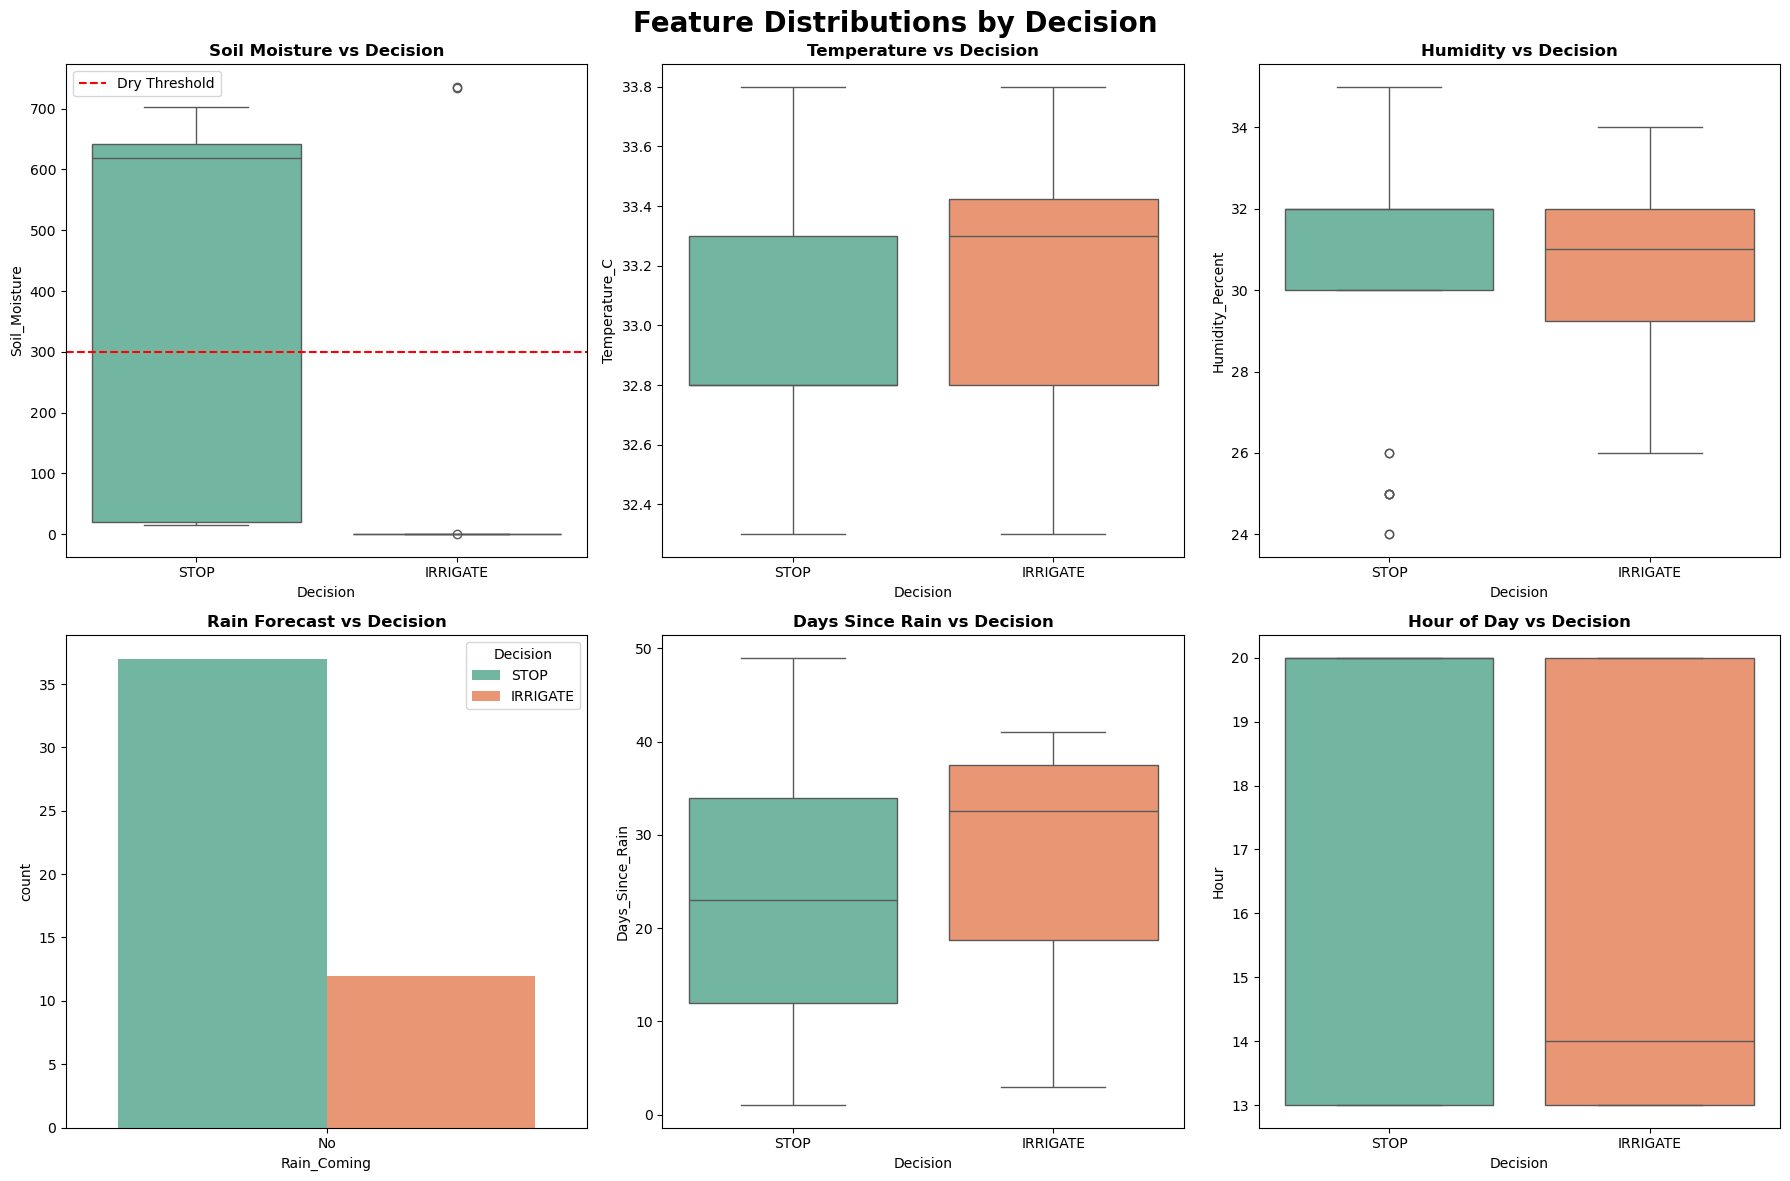


FEATURE CORRELATIONS


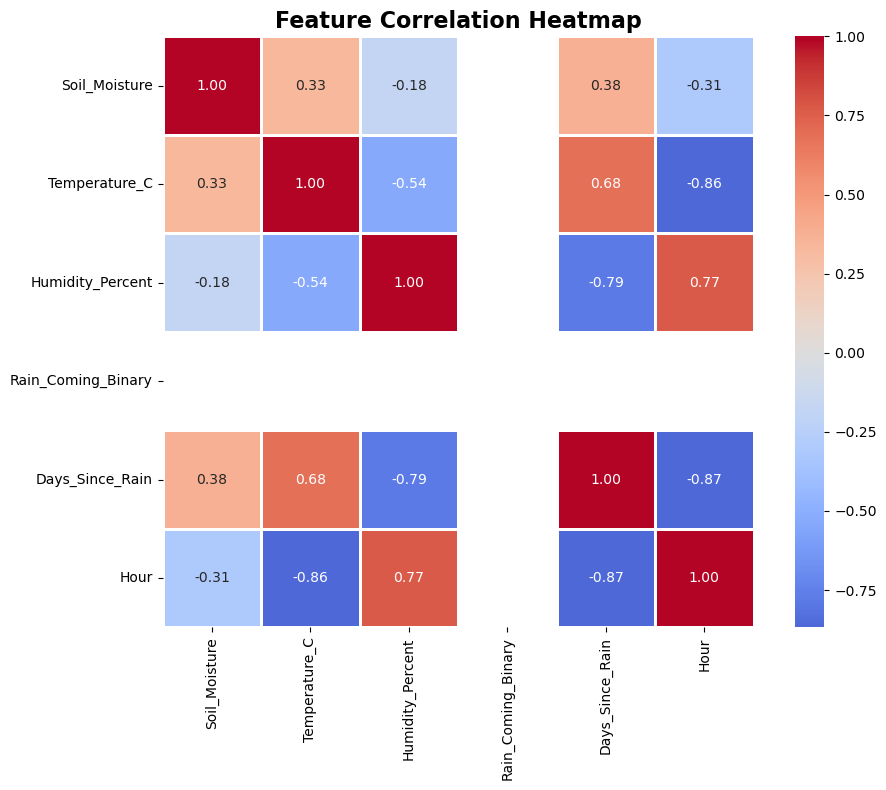

In [7]:
# Analyze relationship between features and decisions

print("="*60)
print("FEATURE ANALYSIS")
print("="*60)

# Select features for analysis
analysis_features = ['Soil_Moisture', 'Temperature_C', 'Humidity_Percent', 
                     'Rain_Coming_Binary', 'Days_Since_Rain', 'Hour']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Feature Distributions by Decision', fontsize=20, fontweight='bold')

# Soil Moisture
sns.boxplot(data=df_clean, x='Decision', y='Soil_Moisture', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Soil Moisture vs Decision', fontweight='bold')
axes[0, 0].axhline(y=300, color='r', linestyle='--', label='Dry Threshold')
axes[0, 0].legend()

# Temperature
sns.boxplot(data=df_clean, x='Decision', y='Temperature_C', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Temperature vs Decision', fontweight='bold')

# Humidity
sns.boxplot(data=df_clean, x='Decision', y='Humidity_Percent', ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Humidity vs Decision', fontweight='bold')

# Rain Coming
sns.countplot(data=df_clean, x='Rain_Coming', hue='Decision', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Rain Forecast vs Decision', fontweight='bold')
axes[1, 0].legend(title='Decision')

# Days Since Rain
sns.boxplot(data=df_clean, x='Decision', y='Days_Since_Rain', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Days Since Rain vs Decision', fontweight='bold')

# Hour of Day
sns.boxplot(data=df_clean, x='Decision', y='Hour', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Hour of Day vs Decision', fontweight='bold')

plt.tight_layout()
plt.show()

# Correlation analysis
print("\n" + "="*60)
print("FEATURE CORRELATIONS")
print("="*60)

correlation_features = ['Soil_Moisture', 'Temperature_C', 'Humidity_Percent', 
                        'Rain_Coming_Binary', 'Days_Since_Rain', 'Hour']
correlation = df_clean[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Prepare features and labels for model training

print("="*60)
print("PREPARING DATA FOR TRAINING")
print("="*60)

# Define feature columns
feature_columns = [
    'Soil_Moisture',
    'Temperature_C', 
    'Humidity_Percent',
    'Rain_Coming_Binary',
    'Days_Since_Rain',
    'Hour',
    'Weather_Humidity',
    'Weather_Temp_C'
]

# Features (X)
X = df_clean[feature_columns]

# Labels (y)
y = df_clean['Decision']

print(f"\n✓ Features prepared")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

print(f"\nFeature columns:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

print(f"\nTarget classes:")
for i, cls in enumerate(sorted(y.unique()), 1):
    print(f"  {i}. {cls}")

# Check if we have enough samples
print(f"\n" + "="*60)
print("SAMPLE SIZE CHECK")
print("="*60)

if len(X) < 100:
    print(f"⚠️  WARNING: Only {len(X)} samples available")
    print("   Recommend collecting at least 100 samples for reliable training")
    print("   Current model will be trained but may have lower accuracy")
else:
    print(f"✓ Good sample size: {len(X)} samples")

# Split data (stratified to maintain class proportions)
if len(X) >= 20:  # Need at least 20 samples to split
    test_size = min(0.2, 10/len(X))  # Use smaller test size if dataset is small
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    print(f"\n✓ Data split complete:")
    print(f"  Training samples: {len(X_train)}")
    print(f"  Testing samples: {len(X_test)}")
    print(f"  Test size: {test_size*100:.1f}%")
    
    print(f"\nTraining set distribution:")
    print(y_train.value_counts())
    
    print(f"\nTesting set distribution:")
    print(y_test.value_counts())
else:
    print(f"\n⚠️  WARNING: Not enough samples to split")
    print(f"   Using entire dataset for training (no test set)")
    X_train, X_test = X, X
    y_train, y_test = y, y

PREPARING DATA FOR TRAINING

✓ Features prepared
Features shape: (49, 8)
Labels shape: (49,)

Feature columns:
  1. Soil_Moisture
  2. Temperature_C
  3. Humidity_Percent
  4. Rain_Coming_Binary
  5. Days_Since_Rain
  6. Hour
  7. Weather_Humidity
  8. Weather_Temp_C

Target classes:
  1. IRRIGATE
  2. STOP

SAMPLE SIZE CHECK
⚠️  WARNING: Only 49 samples available
   Recommend collecting at least 100 samples for reliable training
   Current model will be trained but may have lower accuracy

✓ Data split complete:
  Training samples: 39
  Testing samples: 10
  Test size: 20.0%

Training set distribution:
Decision
STOP        29
IRRIGATE    10
Name: count, dtype: int64

Testing set distribution:
Decision
STOP        8
IRRIGATE    2
Name: count, dtype: int64


TRAINING RANDOM FOREST MODEL

Model parameters:
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: None
  criterion: gini
  max_depth: 10
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 50
  n_jobs: -1
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False

Training model on real data...
✓ Model training complete!

FEATURE IMPORTANCE
              feature  importance
0       Soil_Moisture    0.580619
4     Days_Since_Rain    0.194330
2    Humidity_Percent    0.110429
1       Temperature_C    0.039349
7      Weather_Temp_C    0.033310
6    Weather_Humidity    0.021957
5                Hour    0.020007
3  Rain_Coming_Binary    0.000000


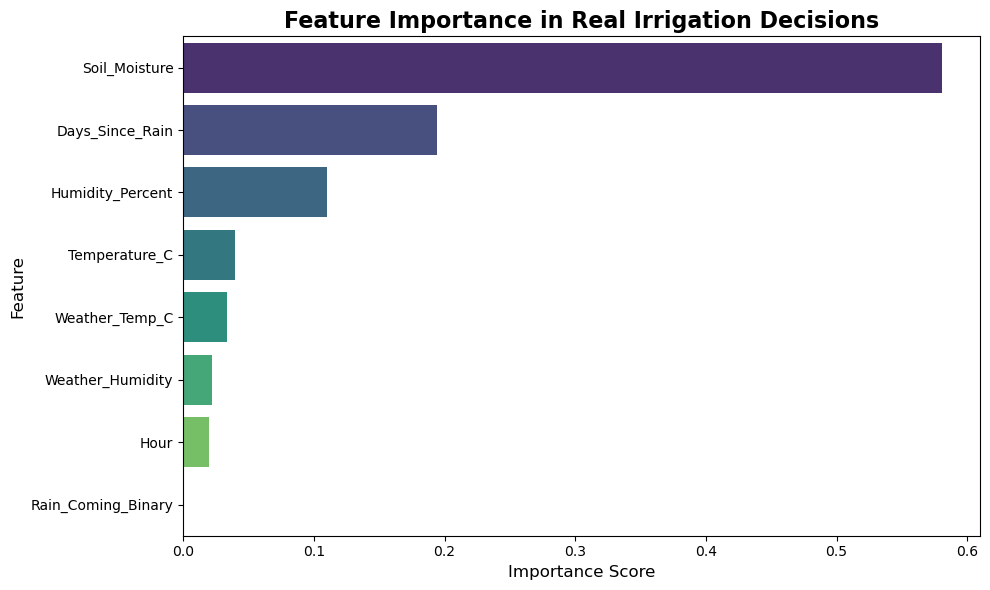


✓ Most important feature: Soil_Moisture
   Importance: 0.5806


In [9]:
# Train Random Forest Classifier on your real data

print("="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

# Initialize Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=50,         # Reduced for smaller dataset
    max_depth=10,            # Limited depth to prevent overfitting
    min_samples_split=2,     # Allow smaller splits
    min_samples_leaf=1,      # Allow single-sample leaves
    random_state=42,
    n_jobs=-1
)

print("\nModel parameters:")
for key, value in model.get_params().items():
    print(f"  {key}: {value}")

# Train the model
print("\nTraining model on real data...")
model.fit(X_train, y_train)

print("✓ Model training complete!")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance in Real Irrigation Decisions', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✓ Most important feature: {feature_importance.iloc[0]['feature']}")
print(f"   Importance: {feature_importance.iloc[0]['importance']:.4f}")

MODEL EVALUATION

✓ Model Accuracy: 100.00%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    IRRIGATE       1.00      1.00      1.00         2
        STOP       1.00      1.00      1.00         8

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


CONFUSION MATRIX
[[2 0]
 [0 8]]


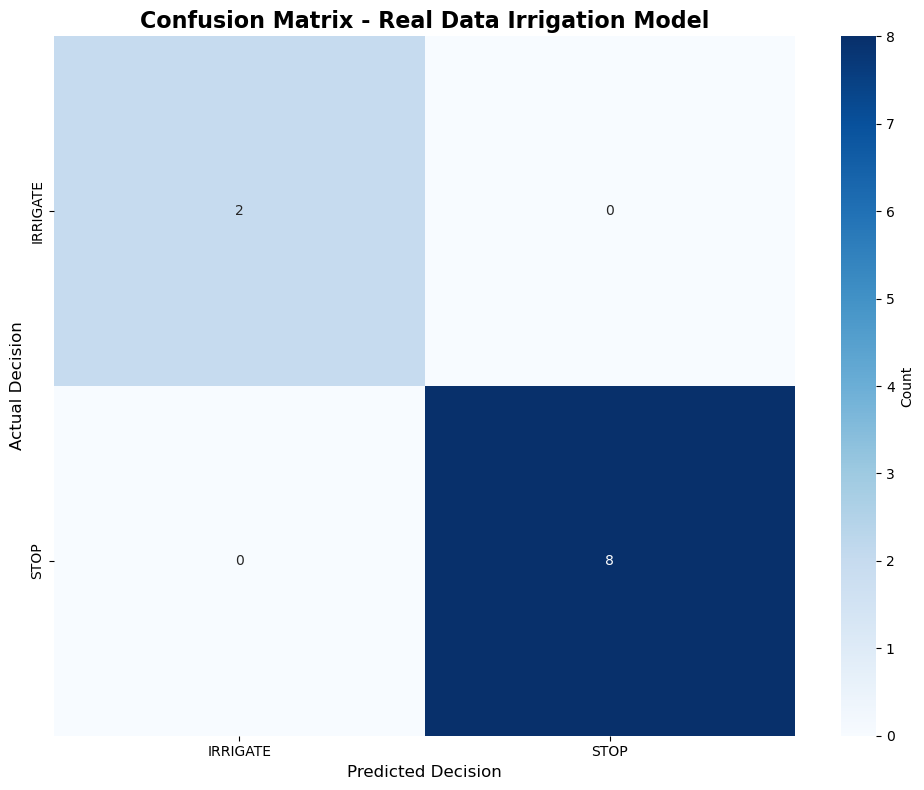


PER-CLASS PERFORMANCE
IRRIGATE: 100.00% accuracy (2/2 correct)
STOP: 100.00% accuracy (8/8 correct)


In [10]:
# Evaluate model on test set

print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✓ Model Accuracy: {accuracy*100:.2f}%")

# Detailed classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes,
            yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Real Data Irrigation Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Decision', fontsize=12)
plt.ylabel('Actual Decision', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)

for i, label in enumerate(classes):
    if cm[i].sum() > 0:
        class_accuracy = cm[i, i] / cm[i].sum() * 100
        print(f"{label}: {class_accuracy:.2f}% accuracy ({cm[i, i]}/{cm[i].sum()} correct)")
    else:
        print(f"{label}: No samples in test set")

In [11]:
# Test model with most recent sensor readings

print("="*60)
print("TESTING WITH RECENT DATA")
print("="*60)

# Get last 5 actual readings
recent_data = df_clean.tail(5)[feature_columns + ['Decision', 'Timestamp']]

print("\nLast 5 sensor readings and predictions:\n")

for idx, row in recent_data.iterrows():
    input_data = row[feature_columns].values.reshape(1, -1)
    
    # Actual decision
    actual = row['Decision']
    
    # Model prediction
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    confidence = max(probabilities) * 100
    
    print(f"{'='*60}")
    print(f"Timestamp: {row['Timestamp']}")
    print(f"Soil Moisture: {row['Soil_Moisture']}")
    print(f"Temperature: {row['Temperature_C']}°C")
    print(f"Humidity: {row['Humidity_Percent']}%")
    print(f"\nActual Decision: {actual}")
    print(f"Model Prediction: {prediction}")
    print(f"Confidence: {confidence:.1f}%")
    print(f"Match: {'✓ YES' if actual == prediction else '✗ NO'}")
    print()

TESTING WITH RECENT DATA

Last 5 sensor readings and predictions:

Timestamp: 2025-10-16 13:55:16
Soil Moisture: 682
Temperature: 33.3°C
Humidity: 24.0%

Actual Decision: STOP
Model Prediction: STOP
Confidence: 100.0%
Match: ✓ YES

Timestamp: 2025-10-16 13:56:22
Soil Moisture: 618
Temperature: 33.3°C
Humidity: 24.0%

Actual Decision: STOP
Model Prediction: STOP
Confidence: 100.0%
Match: ✓ YES

Timestamp: 2025-10-16 13:57:22
Soil Moisture: 629
Temperature: 33.3°C
Humidity: 25.0%

Actual Decision: STOP
Model Prediction: STOP
Confidence: 100.0%
Match: ✓ YES

Timestamp: 2025-10-16 13:58:22
Soil Moisture: 643
Temperature: 33.8°C
Humidity: 25.0%

Actual Decision: STOP
Model Prediction: STOP
Confidence: 100.0%
Match: ✓ YES

Timestamp: 2025-10-16 13:59:23
Soil Moisture: 640
Temperature: 33.8°C
Humidity: 25.0%

Actual Decision: STOP
Model Prediction: STOP
Confidence: 100.0%
Match: ✓ YES



In [12]:
# Save the trained model

print("="*60)
print("SAVING TRAINED MODEL")
print("="*60)

# Create models directory
import os
if not os.path.exists('models'):
    os.makedirs('models')
    print("✓ Created 'models' directory")

# Save the model
model_filename = 'models/irrigation_decision_model_REAL.pkl'
joblib.dump(model, model_filename)
print(f"\n✓ Model saved to: {model_filename}")

# Save feature names and model info
model_info = {
    'feature_columns': feature_columns,
    'target_classes': list(model.classes_),
    'accuracy': float(accuracy),
    'n_samples_total': len(df_clean),
    'n_samples_train': len(X_train),
    'n_samples_test': len(X_test),
    'feature_importance': feature_importance.to_dict('records'),
    'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_source': csv_file
}

import json
info_filename = 'models/model_info_REAL.json'
with open(info_filename, 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"✓ Model info saved to: {info_filename}")

# Save processed dataset
processed_filename = 'models/processed_irrigation_data.csv'
df_clean.to_csv(processed_filename, index=False)
print(f"✓ Processed dataset saved to: {processed_filename}")

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Model Type: Random Forest Classifier")
print(f"Trained on: Real sensor data")
print(f"Total Samples: {len(df_clean)}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Features: {len(feature_columns)}")
print(f"Classes: {len(model.classes_)}")

print(f"\nTop 3 Most Important Features:")
for i in range(min(3, len(feature_importance))):
    row = feature_importance.iloc[i]
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")

print("\n✓ Model ready for integration into Flask app!")
print(f"✓ Use: joblib.load('{model_filename}')")

SAVING TRAINED MODEL
✓ Created 'models' directory

✓ Model saved to: models/irrigation_decision_model_REAL.pkl
✓ Model info saved to: models/model_info_REAL.json
✓ Processed dataset saved to: models/processed_irrigation_data.csv

MODEL SUMMARY
Model Type: Random Forest Classifier
Trained on: Real sensor data
Total Samples: 49
Accuracy: 100.00%
Features: 8
Classes: 2

Top 3 Most Important Features:
  1. Soil_Moisture: 0.5806
  2. Days_Since_Rain: 0.1943
  3. Humidity_Percent: 0.1104

✓ Model ready for integration into Flask app!
✓ Use: joblib.load('models/irrigation_decision_model_REAL.pkl')
